<a href="https://colab.research.google.com/github/fyseo/traffic-vision-yolo/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Road Object Detection

Detecting road users and traffic objects across diverse driving scenes in various weather conditions with the pretrained YOLO11 Nano model.

### Project Sections
* **Section A:** Static image analysis and raw dataset exploration.
* **Section B:** Frame-by-frame batch inference over recorded intersection video footage.
* **Section C:** Real-time stream processing from a live camera feed.

## 1. Environment Setup & Data Installation
Install the required packages, authenticate the Kaggle API, and acquire the dataset for testing. We use the DAWN dataset on Kaggle for static images (Scenario A) and load a local video file for video processing (Scenario B).


In [1]:
# Install core dependencies
%pip install ultralytics opencv-python matplotlib kaggle

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

# --- SCENARIO A: STATIC DAWN IMAGES ---
# Kaggle mirror: about 142 MB.
print("Downloading DAWN dataset...")
!python -m kaggle datasets download -d shuvoalok/dawn-dataset -p dataset/ --unzip

# --- SCENARIO B: VIDEO SAMPLE ---
# Loading a sample video directly from the local project files
sample_video_path = "Sample_Videos/SampleVideo_LowQuality.mp4"

^C



  0%|          | 0.00/132M [00:00<?, ?B/s]
  1%|          | 1.00M/132M [00:00<01:19, 1.72MB/s]
  2%|▏         | 2.00M/132M [00:00<00:52, 2.59MB/s]
  2%|▏         | 3.00M/132M [00:01<00:44, 3.05MB/s]
  3%|▎         | 4.00M/132M [00:01<00:40, 3.33MB/s]
  4%|▍         | 5.00M/132M [00:01<00:37, 3.51MB/s]
  5%|▍         | 6.00M/132M [00:01<00:36, 3.63MB/s]
  5%|▌         | 7.00M/132M [00:02<00:35, 3.70MB/s]
  6%|▌         | 8.00M/132M [00:02<00:34, 3.76MB/s]
  7%|▋         | 9.00M/132M [00:02<00:35, 3.69MB/s]
  8%|▊         | 10.0M/132M [00:03<00:35, 3.58MB/s]
  8%|▊         | 11.0M/132M [00:03<00:36, 3.52MB/s]
  9%|▉         | 12.0M/132M [00:03<00:36, 3.47MB/s]
 10%|▉         | 13.0M/132M [00:04<00:36, 3.44MB/s]
 11%|█         | 14.0M/132M [00:04<00:36, 3.40MB/s]
 11%|█▏        | 15.0M/132M [00:04<00:35, 3.43MB/s]
 12%|█▏        | 16.0M/132M [00:04<00:35, 3.47MB/s]
 13%|█▎        | 17.0M/132M [00:05<00:34, 3.48MB/s]
 14%|█▎        | 18.0M/132M [00:05<00:37, 3.17MB/s]
 14%|█▍        | 19.

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/dawn-dataset
License(s): CC-BY-NC-SA-4.0



## 2. Imports & Model Loading
Initialize the computer vision libraries and load the pre-trained model into memory. We utilize YOLO11 Nano (`yolo11n.pt`) as it offers the best balance of accuracy and real-time processing speeds.

In [64]:
from ultralytics import YOLO
import cv2
import numpy as np
import glob
import random
import matplotlib.pyplot as plt
import math
from IPython.display import HTML, display
import os
import cv2

In [74]:
# Load the YOLO11 Nano model
model = YOLO("yolo11n.pt") 
print(f"Model successfully loaded. Classes available: {model.names}") 

# Target traffic classes from COCO
target_classes = {
    0: "Person",
    1: "Bicycle",
    2: "Car",
    3: "Motorcycle",
    5: "Bus",
    7: "Truck",
    9: "Traffic Light",
    11: "Stop Sign"
}

Model successfully loaded. Classes available: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote',

## 3. Section A: Static Image Object Detection
In this scenario, we evaluate the pre-trained YOLO11 model on static images from the downloaded DAWN dataset:
1. **Data Exploration:** Collect all image paths and sample random images to visualize raw, untouched inputs.
2. **Inference & Detection:** Run detection on each sampled image using the bounding box and annotation pipeline, displaying the detected classes, confidence scores, and object counts.

Total images found in dataset: 1027


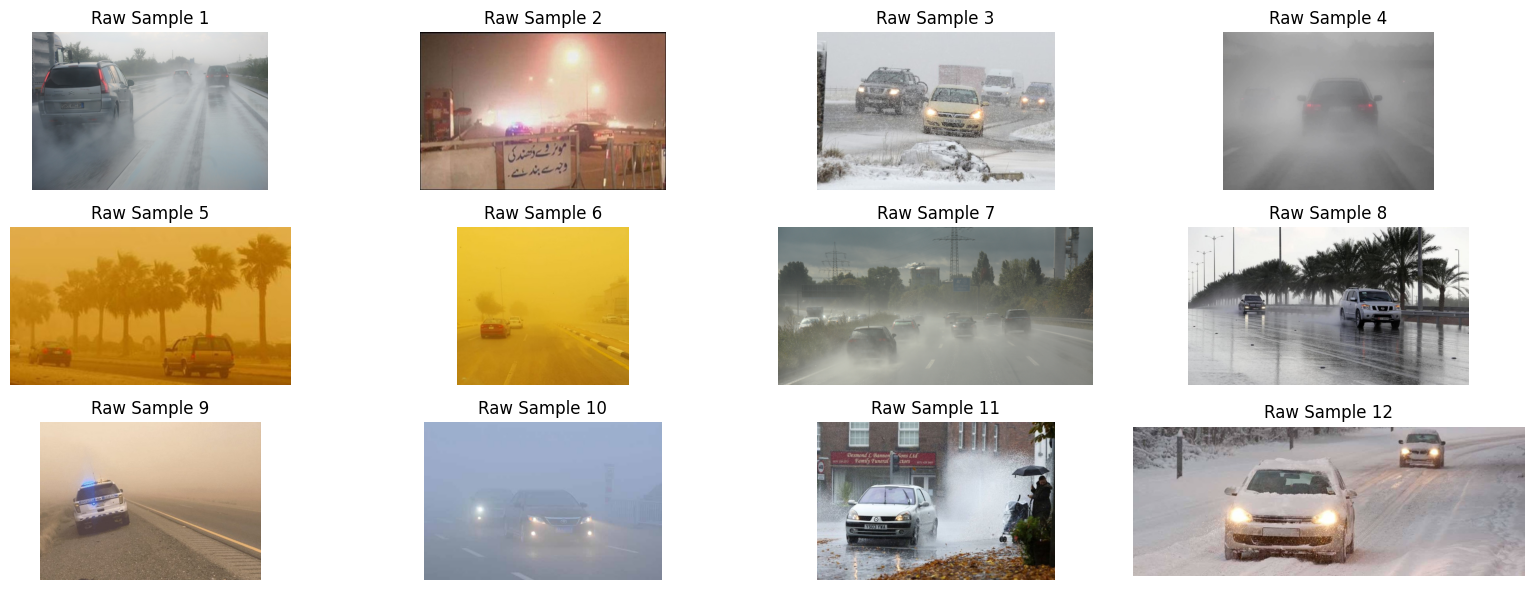

In [44]:
# Gather all image files from the extracted dataset directory
all_images = glob.glob(f"dataset/**/{"*.jpg"}", recursive=True)

print(f"Total images found in dataset: {len(all_images)}")

# Random samples of dataset images
num_samples = 12 
num_cols = 4 # Number of images per row in the visualization
num_rows = math.ceil(num_samples / num_cols)

sample_images = random.sample(all_images, num_samples)

# Visualize raw images before any detection
plt.figure(figsize=(16, 6))

for i in range(num_samples):
    img_bgr = cv2.imread(sample_images[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Raw Sample {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

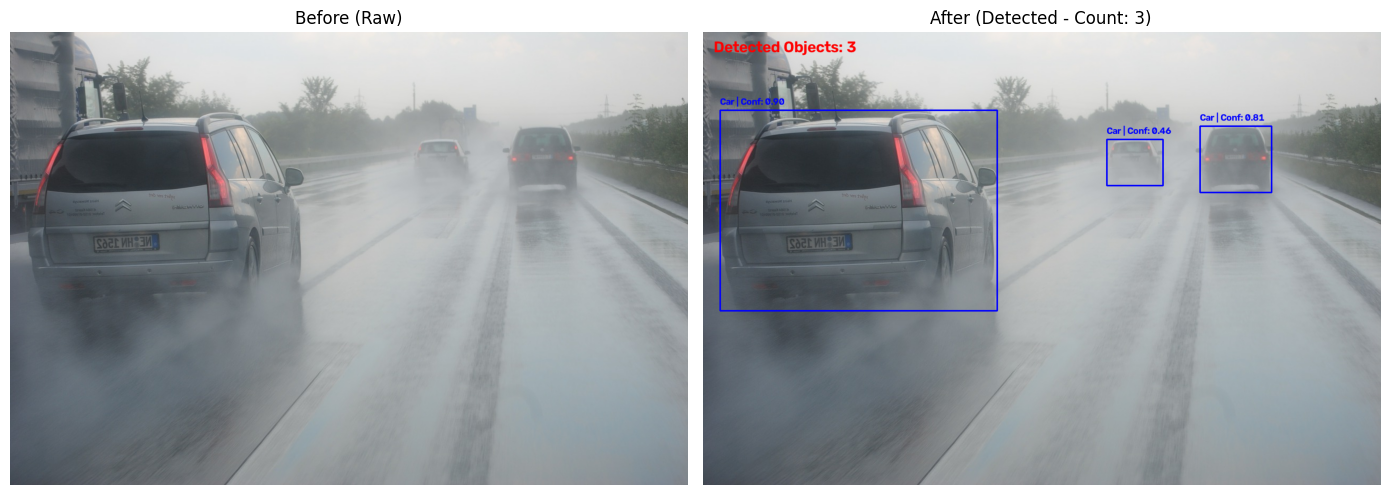

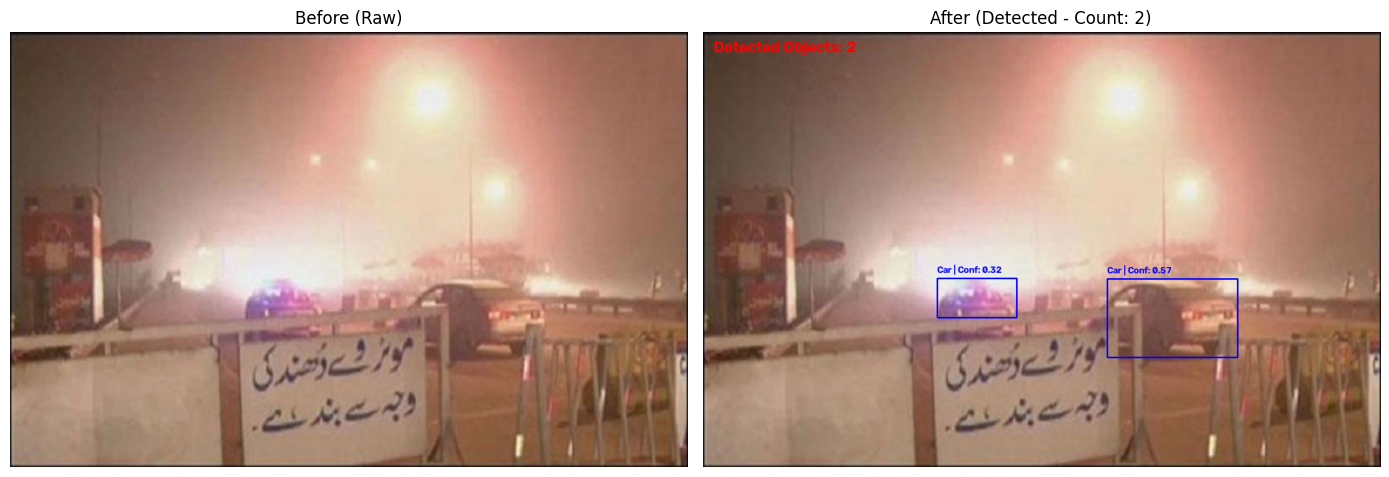

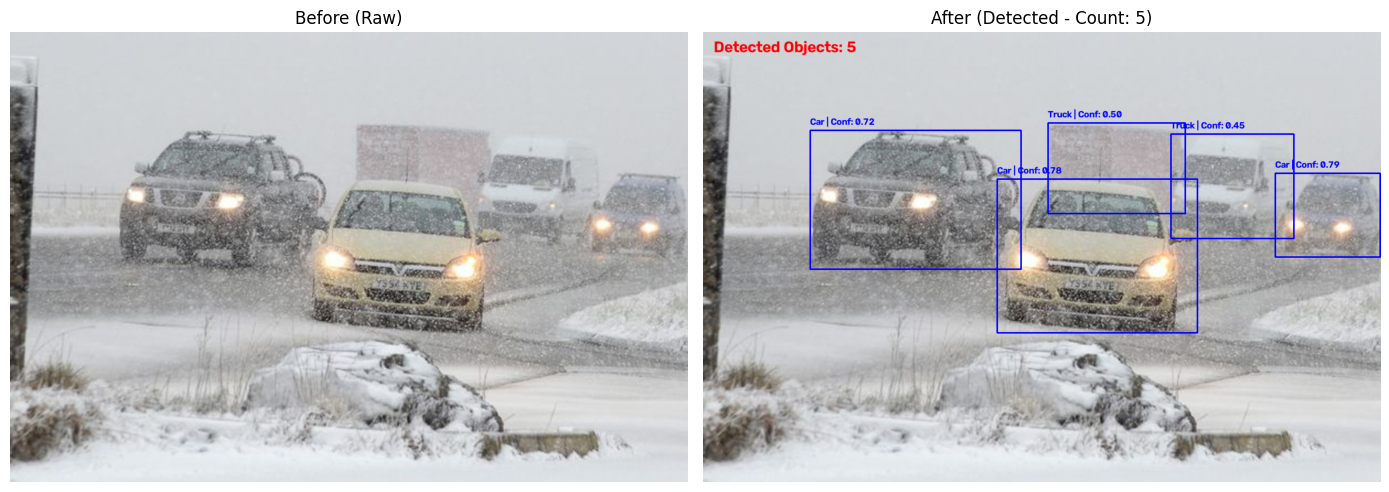

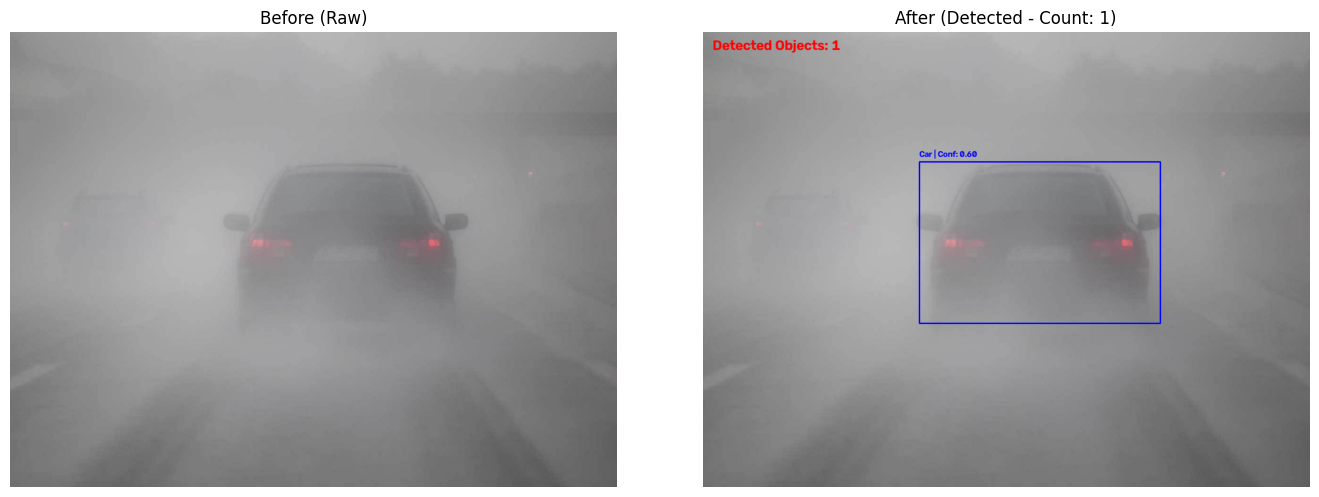

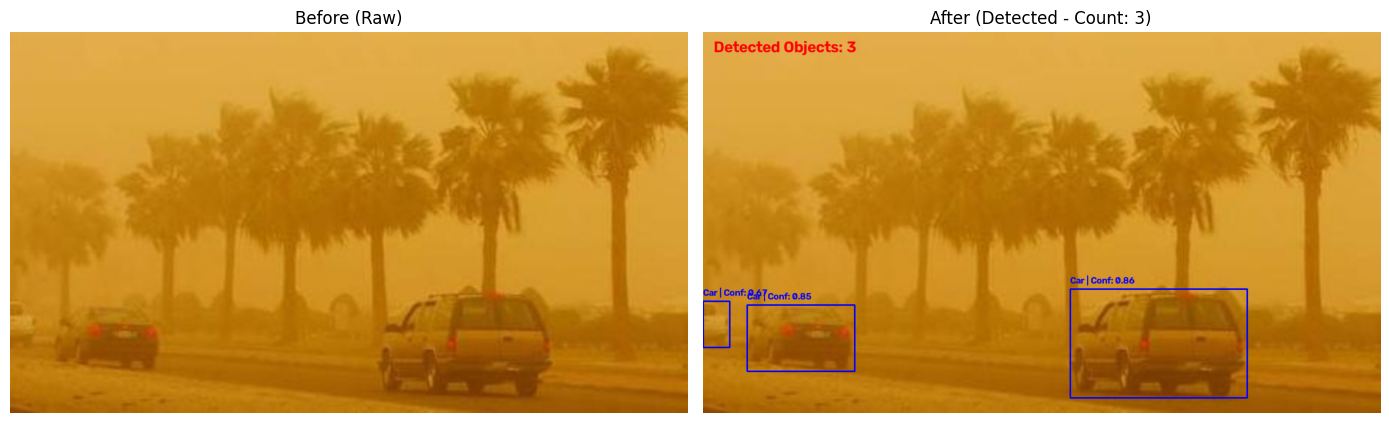

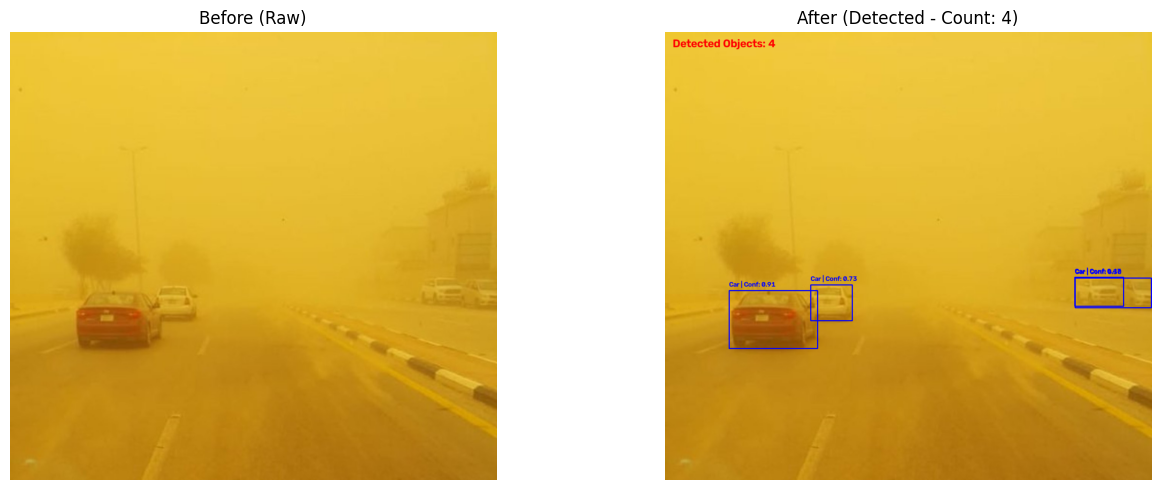

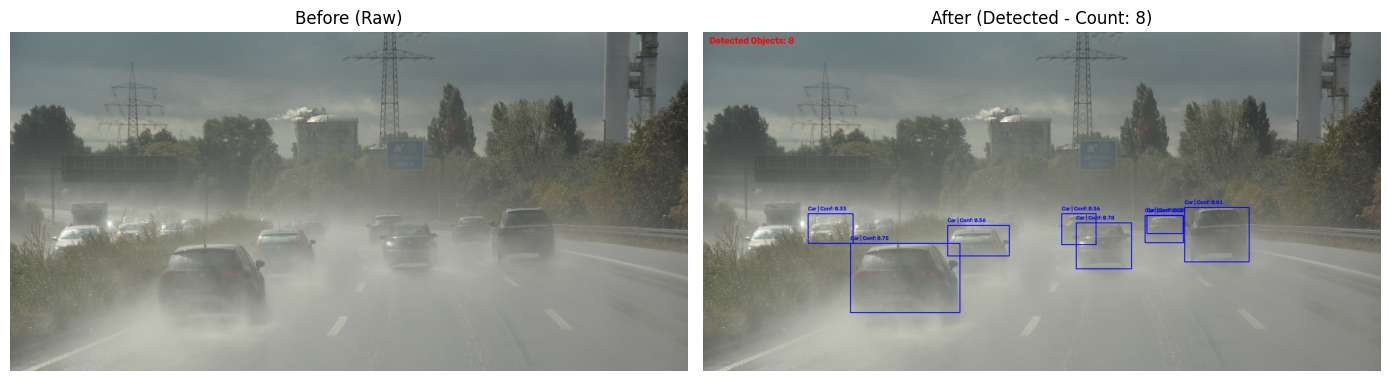

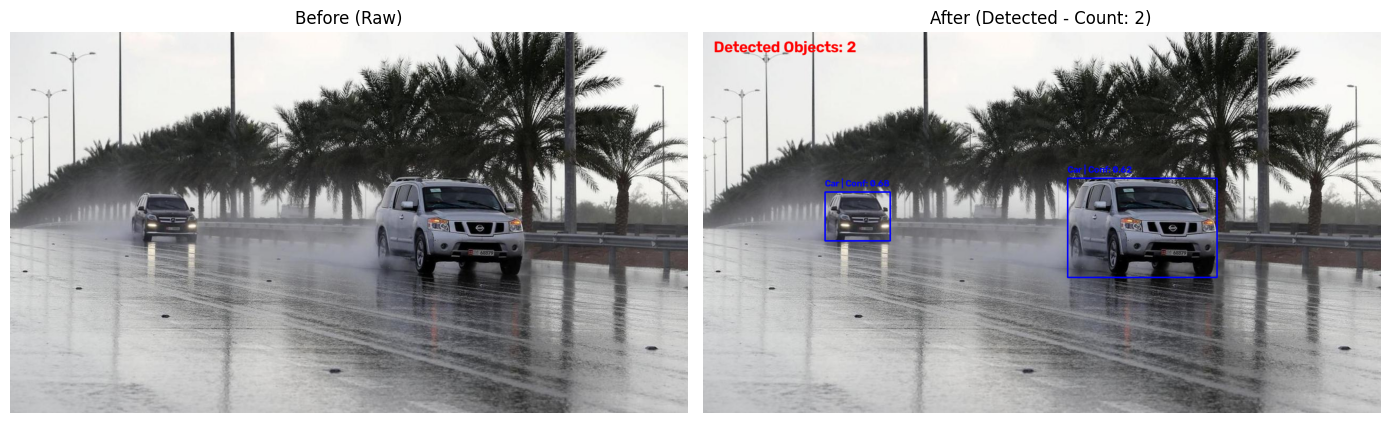

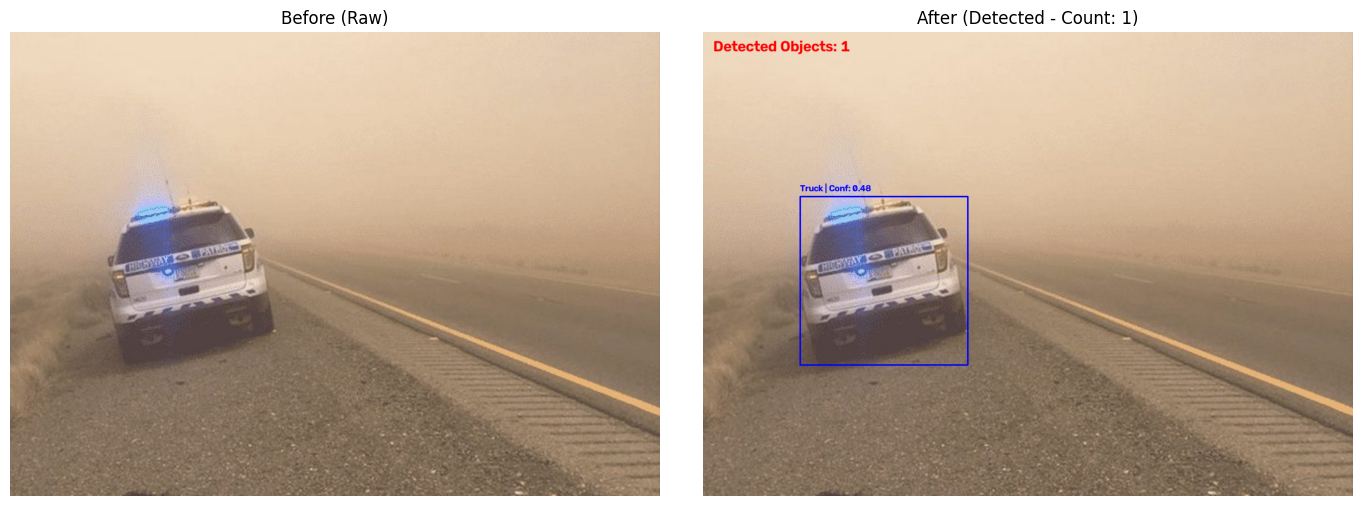

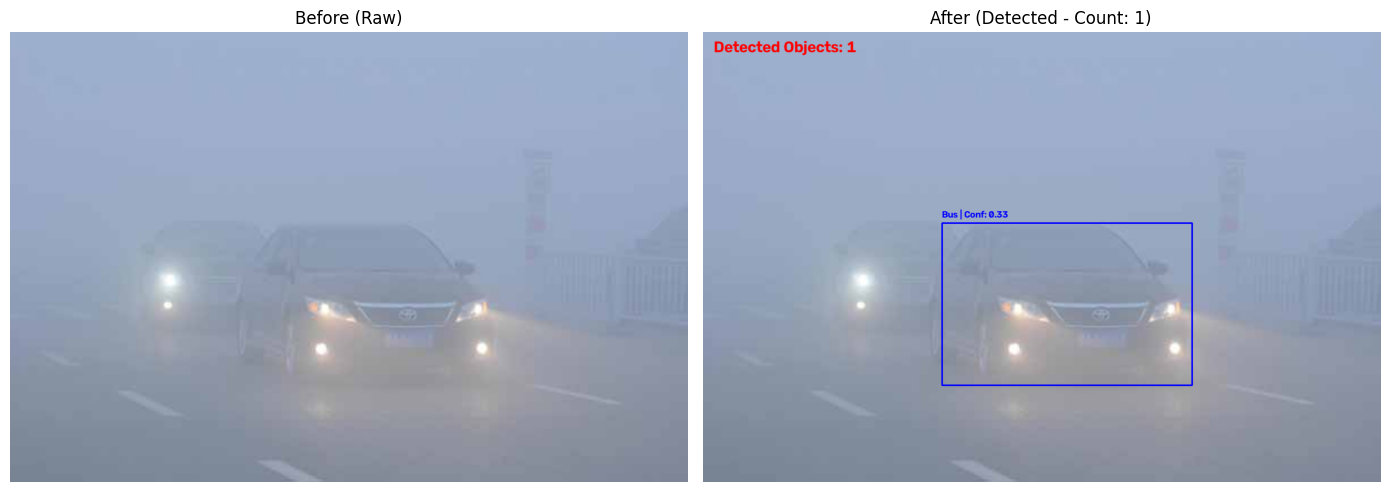

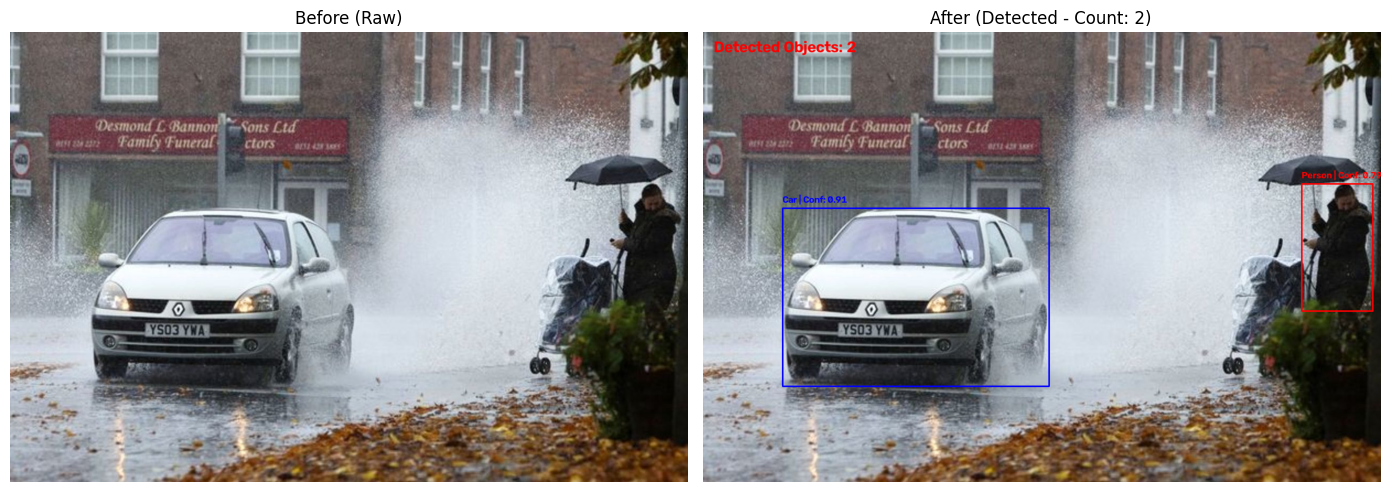

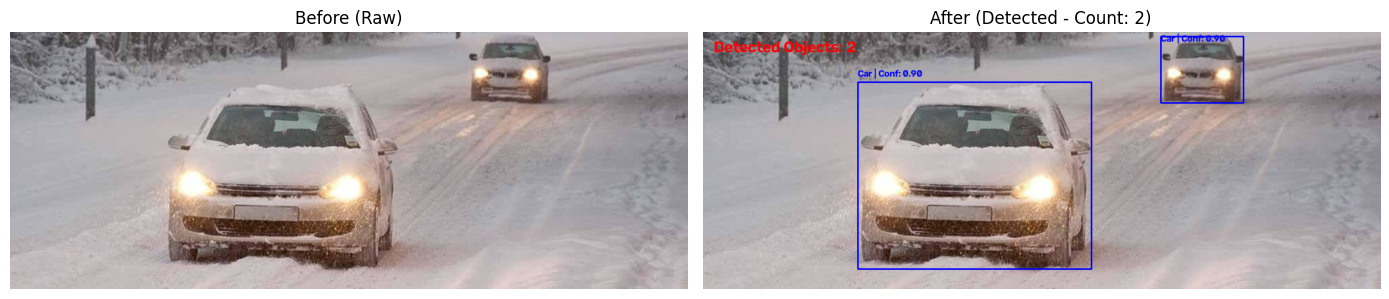

In [ ]:
# Run detection and display results
for i in range(num_samples):
    img_before = cv2.imread(sample_images[i])
    img_after = img_before.copy()
    
    # Run YOLO11 prediction
    results = model.predict(source=img_after, conf=0.3, verbose=False)
    
    detected_count = 0
    for r in results:
        for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
            cls_id = int(cls)
            confidence = float(conf)
            
            # Check if detected object is among target traffic classes
            if cls_id in target_classes:
                detected_count += 1
                x1, y1, x2, y2 = map(int, box)
                label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"
                
                # Distinct bounding box colors by class
                if cls_id == 0:         # Person
                    color = (0, 0, 255)   # Red (BGR)
                elif cls_id in [1, 3]:     # Bicycle / Motorcycle
                    color = (0, 255, 255)   # Yellow (BGR)
                elif cls_id in [2, 5, 7]:  # Car / Bus / Truck
                    color = (255, 0, 0)   # Blue (BGR)
                else: # Traffic Light / Stop Sign
                    color = (0, 255, 0) # Green (BGR)
                
                # Draw bounding box and label
                cv2.rectangle(img_after, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_after, label, (x1, max(y1 - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    # Overlay total detected count in top-left corner
    cv2.putText(img_after, f"Detected Objects: {detected_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2) 
    
    # Display Before vs After side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Before (Raw)")
    axes[0].axis("off")
    
    axes[1].imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"After (Detected - Count: {detected_count})")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

## 4. Section B: Video Detection and Tracking
Process the local sample video (`SampleVideo_LowQuality.mp4`) using two approaches. First, run frame-by-frame object detection as a baseline; then use YOLO11 tracking to associate detections across frames with persistent IDs. Each approach saves a separate annotated output video.

In [81]:
# Method: Frame-by-frame object detection
# Reason: As Studied in the course, this approach establishes a baseline by detecting each frame independently, without persistent track IDs.
# This can lead to flickering of bounding boxes across frames, and inability to track the number of unique objects across frames.


video_out_path_splitting = "video_output_splitting.mp4"

cap = cv2.VideoCapture(sample_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

# Use 'avc1' codec which is web-friendly to show video inline in Jupyter Notebook
out = cv2.VideoWriter(video_out_path_splitting, cv2.VideoWriter_fourcc(*"avc1"), fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO11 detection
    results = model.predict(source=frame, conf=0.3, verbose=False)

    for r in results:
        for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
            cls_id = int(cls)
            confidence = float(conf)

            if cls_id in target_classes:
                x1, y1, x2, y2 = map(int, box)
                label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"
                # Distinct bounding box colors by class
                if cls_id == 0:         # Person
                    color = (0, 0, 255)   # Red (BGR)
                elif cls_id in [1, 3]:     # Bicycle / Motorcycle
                    color = (0, 255, 255)   # Yellow (BGR)
                elif cls_id in [2, 5, 7]:  # Car / Bus / Truck
                     color = (255, 0, 0)   # Blue (BGR)
                else: # Traffic Light / Stop Sign
                    color = (0, 255, 0) # Green (BGR)

                # Draw bounding box and label
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out.write(frame)

cap.release()
out.release()
print(f"Video processing complete. Saved to {video_out_path_splitting}")

# Use HTML5 video tag to display the output video inline in Jupyter Notebook
display(HTML(f'<video src="{video_out_path_splitting}" width="800" controls autoplay loop></video>'))

Video processing complete. Saved to video_output_splitting.mp4


In [82]:
# Method: YOLO11 object tracking
# Reason: Associates detections across frames using persistent track IDs.
# This helps maintain object identity and reduce flickering compared with frame-by-frame detection.

video_out_path_tracking = "video_output_tracking.mp4"

cap = cv2.VideoCapture(sample_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

cap.release()

# Use 'avc1' codec which is web-friendly to show video inline in Jupyter Notebook
out = cv2.VideoWriter(video_out_path_tracking, cv2.VideoWriter_fourcc(*"avc1"), fps, (width, height))


# Run tracking
results = model.track(
    source=sample_video_path, 
    conf=0.3, 
    classes=[0, 1, 2, 3, 5, 7, 9, 11], 
    persist=True, # enables object ID tracking
    stream=True, # keeps RAM usage low
    verbose=False
)

for r in results:
    # r.plot() automatically draws bounding boxes, tracking paths, and labels
    out.write(r.plot())  

out.release()
print(f"Video processing complete. Saved to {video_out_path_tracking}")

# Use HTML5 video tag to display the output video inline in Jupyter Notebook
display(HTML(f'<video src="{video_out_path_tracking}" width="800" controls autoplay loop></video>'))

Video processing complete. Saved to video_output_tracking.mp4


## 5. Section C: Live Camera Inference
Run real-time object detection using the local machine's webcam. A window will open displaying the live feed with bounding boxes and class labels. **Press the 'q' key** while the window is active to safely terminate the stream and release the camera.

In [ ]:
# CHECK BEFORE U RUN_________________________________-----------------
# --- SCENARIO C: LIVE CAMERA FEED ---
# Note: 'model' and 'target_classes' are carried over from Section 3.

# 0 is the default ID for the built-in webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open the webcam. Check your privacy settings or camera index.")
else:
    print("Starting live feed... Click the video window and press 'q' to quit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break
            
        # Run YOLO11 detection
        results = model.predict(source=frame, conf=0.4, verbose=False)
        
        detected_count = 0
        for r in results:
            for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
                cls_id = int(cls)
                confidence = float(conf)
                
                # Filter by intersection/traffic classes
                if cls_id in target_classes:
                    detected_count += 1
                    x1, y1, x2, y2 = map(int, box)
                    label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"
                    
                    # Distinct bounding box colors # add it so that for this live feed it displayes different colors for different classes not only these 4
                    if cls_id in [2, 7]:       # Car / Truck
                        color = (0, 0, 255)    # Red
                    elif cls_id in [1, 3, 5]:  # Bicycle / Motorcycle / Bus
                        color = (255, 0, 0)    # Blue
                    elif cls_id == 0:          # Person
                        color = (0, 255, 0)    # Green
                    elif cls_id == 32:          # Sports Ball
                        color = (255, 0, 255)  # Magenta
                    else:
                        color = (0, 255, 255)  # Yellow
                        
                    # Draw bounding box and label
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        # Display detection count in the corner
        cv2.putText(frame, f"Live Objects: {detected_count}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        
        # Render the live window
        cv2.imshow("Live Intersection Detection", frame)
        
        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Clean up the camera and close the window safely
    cap.release()
    cv2.destroyAllWindows()
    print("Live feed terminated safely.")

Starting live feed... Click the video window and press 'q' to quit.
Live feed terminated safely.
